In [47]:
import pandas as pd
import torch
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import numpy as np
import torch.nn.functional as F
import torch.nn as nn


In [48]:
df = pd.read_csv("C:\\Users\\j\\Desktop\\pytorch-tutorials\\data.csv")
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [49]:
df.shape

(569, 33)

In [50]:
df.drop(columns = ["id", "Unnamed: 32"], inplace = True)

In [51]:
x = df.drop(columns = ["diagnosis"])
y = df["diagnosis"]

In [52]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [53]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [54]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

## converting numpy into tensors

In [55]:
x_train_tensor = torch.from_numpy(x_train).float()
x_test_tensor = torch.from_numpy(x_test).float()

y_train_tensor = torch.from_numpy(y_train).float().unsqueeze(1)
y_test_tensor = torch.from_numpy(y_test).float().unsqueeze(1)

## Defining model

In [56]:
class MyANNmodel():

    def __init__(self, x):

        self.weights = torch.rand(x.shape[1], 1, dtype = torch.float32, requires_grad = True)
        self.bias = torch.zeros(1, dtype = torch.float32, requires_grad = True)
        
    def forwardpass(self,x):
        z = torch.matmul(x, self.weights) + self.bias
        y_pred = torch.sigmoid(z)
        return y_pred

In [57]:
learning_rate = 0.1
epochs = 5

In [58]:
model = MyANNmodel(x_train_tensor)

In [59]:
model.weights

tensor([[0.8770],
        [0.2752],
        [0.7173],
        [0.6428],
        [0.8583],
        [0.3596],
        [0.1407],
        [0.3102],
        [0.2659],
        [0.5164],
        [0.2447],
        [0.9816],
        [0.9991],
        [0.5284],
        [0.8484],
        [0.7532],
        [0.9733],
        [0.6593],
        [0.6554],
        [0.8237],
        [0.5184],
        [0.0863],
        [0.9399],
        [0.0879],
        [0.4421],
        [0.0191],
        [0.7199],
        [0.2963],
        [0.3482],
        [0.6887]], requires_grad=True)

## Training model

In [60]:
# creating model


# training loop
for epoch in range(epochs):
    
    # creating forward pass
    y_pred = model.forwardpass(x_train_tensor)
    
    # loss function
    
    loss = F.binary_cross_entropy(y_pred, y_train_tensor, reduction = "mean"   )
    
    
    # backward pass
    loss.backward()
    
    # parameter optimization
    with torch.no_grad(): # to off gradient tracking 
        model.weights -= learning_rate * model.weights.grad
        model.bias -= learning_rate * model.bias.grad
        
    # zero gradients
    model.weights.grad.zero_()
    model.bias.grad.zero_()
    
    # print loss
    print(f"epoch: {epoch + 1} loss: {loss.item():.4f}")

epoch: 1 loss: 1.2851
epoch: 2 loss: 1.0835
epoch: 3 loss: 1.0665
epoch: 4 loss: 1.0497
epoch: 5 loss: 1.0319


In [61]:
model.weights

tensor([[0.9144],
        [0.2925],
        [0.7511],
        [0.6756],
        [0.8345],
        [0.3234],
        [0.1275],
        [0.3149],
        [0.2402],
        [0.4424],
        [0.2492],
        [0.9463],
        [0.9966],
        [0.5395],
        [0.7851],
        [0.6810],
        [0.9259],
        [0.6137],
        [0.6132],
        [0.7418],
        [0.5571],
        [0.1119],
        [0.9738],
        [0.1206],
        [0.4351],
        [0.0012],
        [0.7138],
        [0.3083],
        [0.3625],
        [0.6443]], requires_grad=True)

## Evaluation

In [62]:
y_pred = model.forwardpass(x_test_tensor)

In [63]:
y_pred = (y_pred > 0.9).float()
accuracy = (y_pred == y_test_tensor).float().mean()
print(f"accuracy: {accuracy:.4f}")

accuracy: 0.9035


# Training Neural Network using NN module

In [64]:
class MyModule(nn.Module):
    
    def __init__(self, features):
        
        super().__init__()
        self.linear = nn.Linear(features, 1)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, features):
        out = self.linear(features)
        out = self.sigmoid(out)
        return out
    
    #def loss(self, y_pred, y_true):
        return F.binary_cross_entropy(y_pred, y_true, reduction = "mean")
        

In [65]:
# we can use direct nn modules and functions instead of creating our own as given above
loss_function = nn.BCELoss()  # upar wala loss fuction manaul banaya h or ye nn module ke andar bana hua hai

In [66]:
model = MyModule(x_train_tensor.shape[1])

# ham optimizer ko bhi nn module nn.optim se use kar sakte h
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for epoch in range(epochs):
    
    # Forward pass
    y_pred = model(x_train_tensor)
    
    # Loss function
    loss = loss_function(y_pred, y_train_tensor)
    
    # finding gradients 
    loss.backward()
    
    # parameter optimization using gradient descent
    #with torch.no_grad():
        #model.linear.weight -= learning_rate * model.linear.weight.grad
        #model.linear.bias -= learning_rate * model.linear.bias.grad
    optimizer.step()  # ye optimizer ke andar hi gradients ko update karne ka code hota h
    
    # making gradients zero so that they don't accumulate in the next iteration
    #model.linear.weight.grad.zero_()
    #model.linear.bias.grad.zero_()
    optimizer.zero_grad()  # ye optimizer ke andar hi gradients ko zero karne ka code hota h
    
    print(f"epoch: {epoch +1} loss: {loss.item():.4f}")

epoch: 1 loss: 0.7098
epoch: 2 loss: 0.5453
epoch: 3 loss: 0.4579
epoch: 4 loss: 0.4035
epoch: 5 loss: 0.3657


In [67]:
# testing the model
y_pred = model.forward(x_test_tensor)

In [68]:
y_pred = (y_pred > 0.9).float()
accuracy = (y_pred == y_test_tensor).float().mean()
print(f"accuracy: {accuracy:.4f}")

accuracy: 0.7456


In above model we used SGD which raise memory issue and convergence issue, thus we will use Mini batch GD.
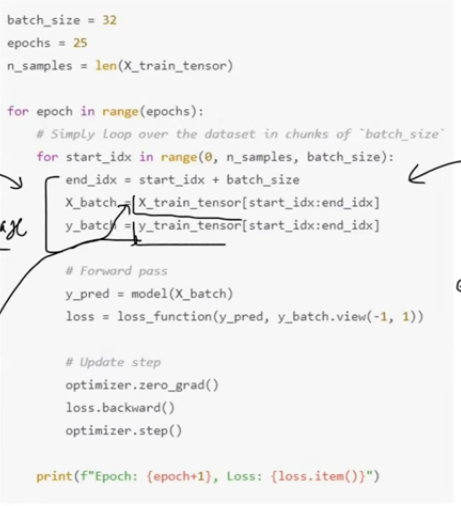 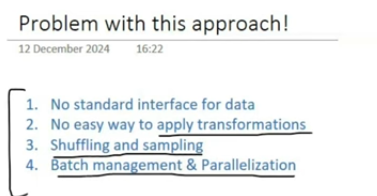

ye method kam to kar dega lekin effient nhi hoga especially on large and complex dataset

To resolve these issues we will use 

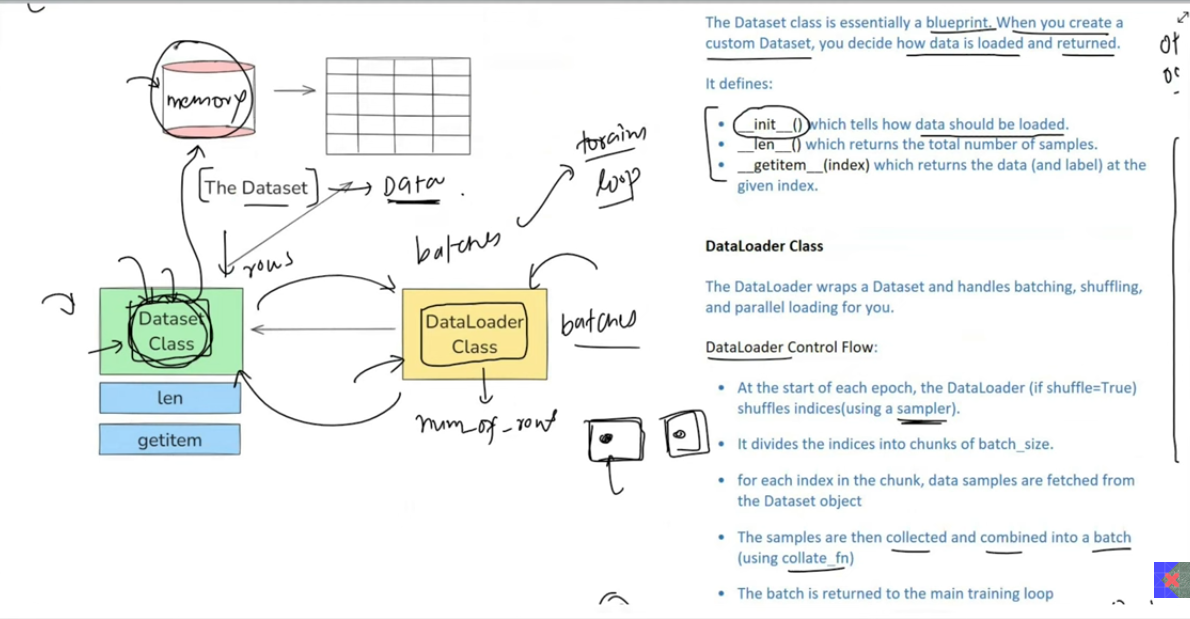